In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
from joblib import Parallel, delayed
from tqdm import tqdm

In [ ]:
from utils import DataHandler
from ESN import ESNetwork
from reservoirs import CPRC

In [ ]:
window_size = 20
n_samples = 10000
tau = 17
# X, Y = DataHandler().load_dataset('narma', n_samples = 1000, window_size=4, plot=True)
X, Y = DataHandler().load_dataset('mackey_glass', n_samples = n_samples, tau = tau, window_size=window_size,prediction_horizon=20, plot=True)

In [ ]:
tr = 0.75
train_size = int(n_samples*tr)  # Training set size
# Split into training and testing sets
X_train_, X_test_ = X[:train_size], X[train_size:]
y_train, y_test = Y[:train_size], Y[train_size:]

In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_)
X_test = scaler.transform(X_test_) 

In [ ]:
itr = 20
a = 0.01
b = 1
limits = np.linspace(a,b,itr)

In [ ]:
def evaluate_limit(i, X_train, y_train, X_test, y_test, limits):
    try:
        dim = len(X_train[0])
        CP_params = [0.1499956344663278, np.pi/7, -np.pi/3, 7*np.pi/7, np.pi/9, -np.pi/7]

        cprc = CPRC(dim=dim, execution_mode='simulation', CP_params=CP_params, kernel=True)
        esn = ESNetwork(
            reservoir=cprc,
            dim=dim,
            regularization=1e-6,
            alpha=0.79,
            show_progress=False,
            approach='feedback',
            model_type='ridge',
            limit=limits[i],
            cpk=True
        )

        esn.fit(X_train, y_train)
        predictions = esn.predict(X_test)
        mse = mean_squared_error(y_test, predictions)
        return mse

    except Exception as e:
        return f"Error at index {i}: {e}"


In [ ]:
itr = len(limits)

mserror = Parallel(n_jobs=-1)(
    delayed(evaluate_limit)(i, X_train, y_train, X_test, y_test, limits)
    for i in tqdm(range(itr))
)

In [ ]:
import pandas as pd
df = pd.DataFrame([mserror], columns=[f"mse_{i}" for i in range(len(mserror))])
df.insert(0, "tau", tau) 
df.to_csv(f"../Paper_results/mse_limit_{tau}_normalized.csv", index=False)

In [ ]:
import matplotlib.ticker as ticker
param_values = limits  
errors = mserror     

# Find the minimum
min_idx = np.argmin(errors)
min_limit = param_values[min_idx]
min_mse = errors[min_idx]

# Plot
plt.figure(figsize=(8, 5))
plt.plot(param_values[1:], errors[1:], marker='o', linestyle='-', label="MSE")

# Add arrow annotation
ax = plt.gca()
ax.annotate(
    f"Min: ({min_limit:.2f}, {min_mse:.1e})",
    xy=(min_limit, min_mse),             # point to annotate
    xytext=(min_limit - 0.3, min_mse * 30),  # arrowhead to label position
    textcoords='data',
    arrowprops=dict(arrowstyle="->", color='red', linewidth=1.5),
    fontsize=10,
    ha='left'
)

ax = plt.gca()
ax.yaxis.set_major_formatter(ticker.ScalarFormatter(useMathText=True))
ax.ticklabel_format(axis='y', style='sci', scilimits=(0, 0))
# Labels and grid
plt.xlabel("\u03BB")
plt.ylabel("Mean Squared Error")
# plt.title("Performance of Quantum Reservoir vs \u03BB")
plt.grid(True)
plt.tight_layout()

plt.savefig("../Paper_results/figures/qrc_lambda_vs_mse.pdf")
plt.show()


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np

itr = 20
a = 0.00001
b = 1
c = 0.01
alphas = np.linspace(a,b,itr)
limits = np.linspace(c,b,itr)

tau = 17  
# Load both result files
df_limit = pd.read_csv(f"../Paper_results/mse_limit_{tau}_normalized.csv")
df_alpha = pd.read_csv(f"../Paper_results/mse_alpha_{tau}_normalized.csv")

# Extract data
# limits = [float(col.replace("mse_", "")) for col in df_limit.columns if "mse_" in col]
mse_limits = df_limit.values[0][1:]

# alphas = [float(col.replace("mse_", "")) for col in df_alpha.columns if "mse_" in col]
mse_alphas = df_alpha.values[0][1:]

# Find minima
min_idx_l = np.argmin(mse_limits)
min_l, min_mse_l = limits[min_idx_l], mse_limits[min_idx_l]

min_idx_a = np.argmin(mse_alphas)
min_a, min_mse_a = alphas[min_idx_a], mse_alphas[min_idx_a]

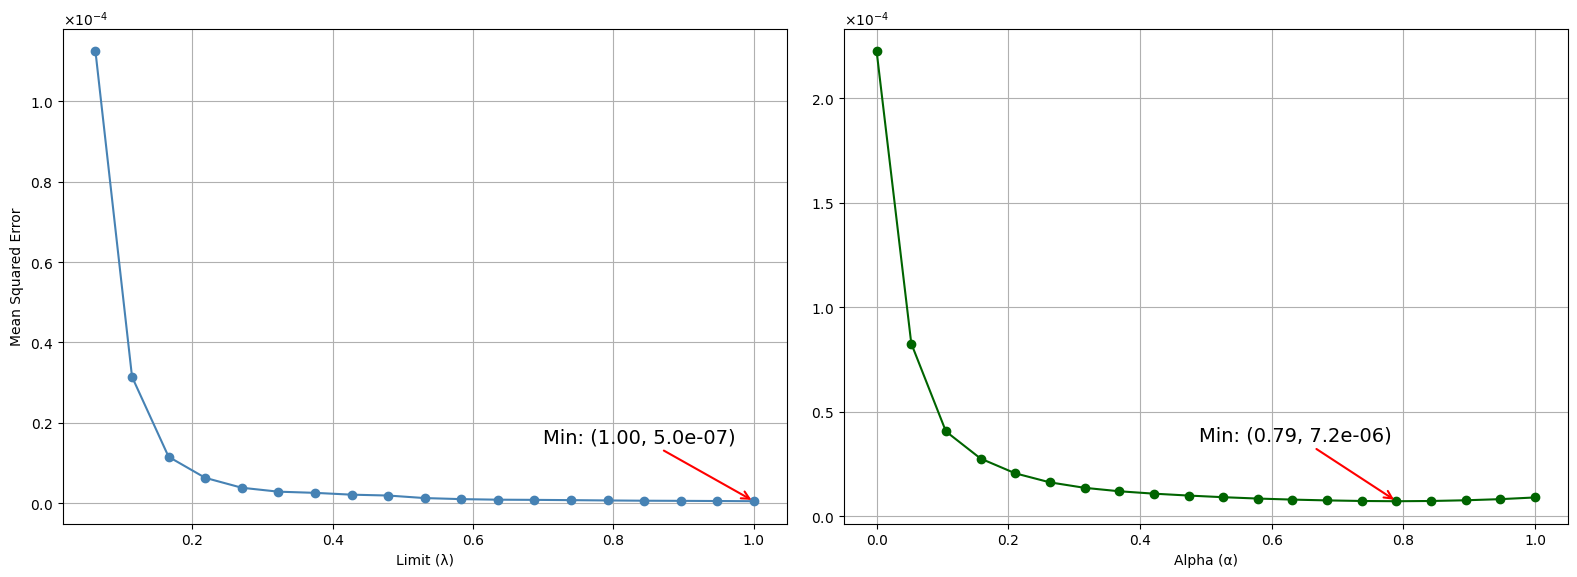

In [3]:
fig, axs = plt.subplots(1, 2, figsize=(16, 6))  # independent y-axes
plt.rcParams['font.size'] = 14
plt.rcParams['axes.labelsize'] = 14  # For axis labels
plt.rcParams['xtick.labelsize'] = 14 # For x-axis tick labels
plt.rcParams['ytick.labelsize'] = 14
# --- Plot 1: Limit vs MSE ---
axs[0].plot(limits[1:], mse_limits[1:], marker='o', linestyle='-', color='steelblue', label="MSE")
axs[0].annotate(
    f"Min: ({min_l:.2f}, {min_mse_l:.1e})",
    xy=(min_l, min_mse_l),
    xytext=(min_l - 0.3, min_mse_l * 30),
    textcoords='data',
    arrowprops=dict(arrowstyle="->", color='red', lw=1.5),
    fontsize=14,
    ha='left'
)
axs[0].set_xlabel("Limit (\u03BB)")
axs[0].set_ylabel("Mean Squared Error")
# axs[0].set_title("MSE vs Limit")
axs[0].grid(True)

# --- Plot 2: Alpha vs MSE ---
axs[1].plot(alphas, mse_alphas, marker='o', linestyle='-', color='darkgreen', label="MSE")
axs[1].annotate(
    f"Min: ({min_a:.2f}, {min_mse_a:.1e})",
    xy=(min_a, min_mse_a),
    xytext=(min_a - 0.3, min_mse_a * 5),
    textcoords='data',
    arrowprops=dict(arrowstyle="->", color='red', lw=1.5),
    fontsize=14,
    ha='left'
)
axs[1].set_xlabel("Alpha (\u03B1)")
# axs[1].set_title("MSE vs Alpha")
axs[1].grid(True)

# Apply scientific notation formatting
for ax in axs:
    ax.yaxis.set_major_formatter(ticker.ScalarFormatter(useMathText=True))
    ax.ticklabel_format(axis='y', style='sci', scilimits=(0, 0))

plt.tight_layout()
# plt.savefig("../Paper_results/figures/qrc_lambda_alpha_vs_mse.pdf")
plt.show()


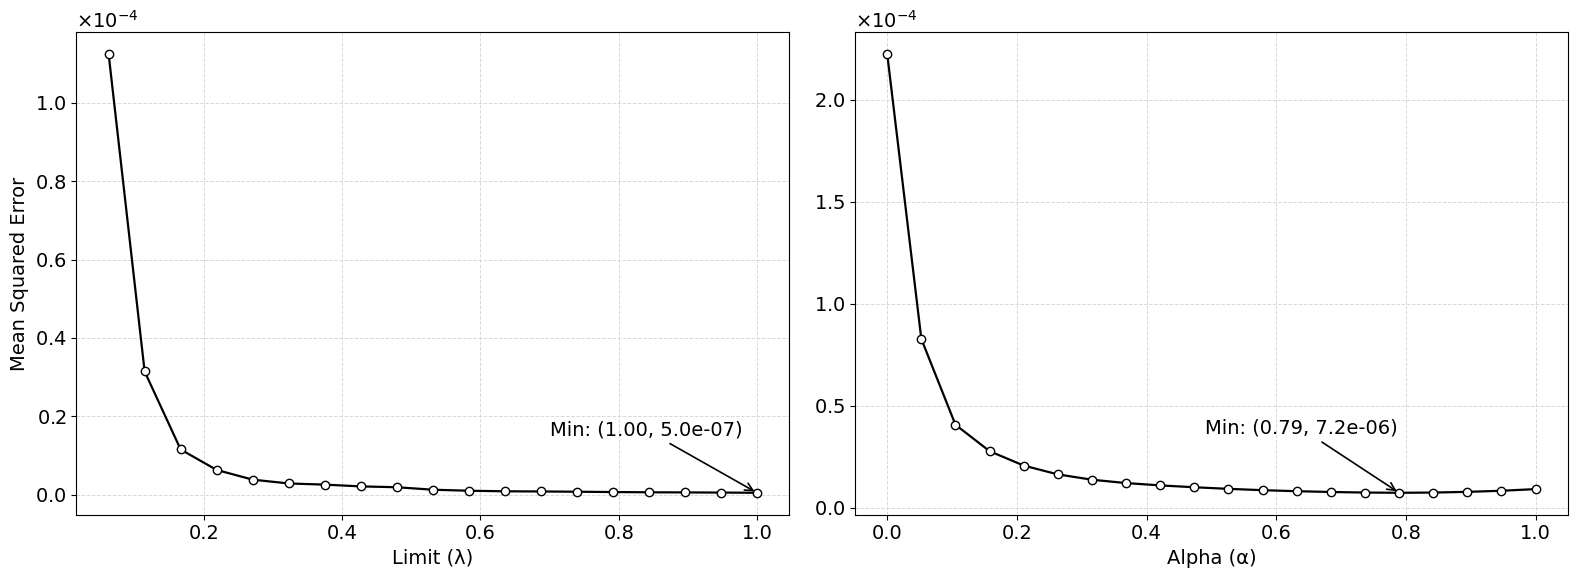

In [6]:
import matplotlib.pyplot as plt
from matplotlib import ticker

# Fonts (already close to what you had)
# plt.rcParams['font.size'] = 14
# plt.rcParams['axes.labelsize'] = 14
# plt.rcParams['xtick.labelsize'] = 14
# plt.rcParams['ytick.labelsize'] = 14

fig, axs = plt.subplots(1, 2, figsize=(16, 6))  # independent y-axes

# --- Plot 1: Limit vs MSE (black line, hollow markers) ---
axs[0].plot(
    limits[1:], mse_limits[1:],
    marker='o', linestyle='-',
    color='0.0', markerfacecolor='1.0', markeredgecolor='0.0', linewidth=1.6
)
axs[0].annotate(
    f"Min: ({min_l:.2f}, {min_mse_l:.1e})",
    xy=(min_l, min_mse_l),
    xytext=(min_l - 0.3, min_mse_l * 30),
    textcoords='data',
    arrowprops=dict(arrowstyle="->", color='0.0', lw=1.2),
    fontsize=14, ha='left', color='0.0'
)
axs[0].set_xlabel("Limit (\u03BB)", color='0.0')
axs[0].set_ylabel("Mean Squared Error", color='0.0')
axs[0].grid(True, linestyle='--', linewidth=0.7, color='0.85')

# --- Plot 2: Alpha vs MSE (black line, hollow markers) ---
axs[1].plot(
    alphas, mse_alphas,
    marker='o', linestyle='-',
    color='0.0', markerfacecolor='1.0', markeredgecolor='0.0', linewidth=1.6
)
axs[1].annotate(
    f"Min: ({min_a:.2f}, {min_mse_a:.1e})",
    xy=(min_a, min_mse_a),
    xytext=(min_a - 0.3, min_mse_a * 5),
    textcoords='data',
    arrowprops=dict(arrowstyle="->", color='0.0', lw=1.2),
    fontsize=14, ha='left', color='0.0'
)
axs[1].set_xlabel("Alpha (\u03B1)", color='0.0')
axs[1].grid(True, linestyle='--', linewidth=0.7, color='0.85')

# Axes/ticks color to black
for ax in axs:
    ax.tick_params(axis='both', colors='0.0')
    ax.spines['bottom'].set_color('0.0')
    ax.spines['left'].set_color('0.0')
    ax.spines['right'].set_color('0.0')
    ax.spines['top'].set_color('0.0')
    # Scientific notation formatting
    ax.yaxis.set_major_formatter(ticker.ScalarFormatter(useMathText=True))
    ax.ticklabel_format(axis='y', style='sci', scilimits=(0, 0))

plt.tight_layout()
plt.savefig("../Paper_results/figures/bw_qrc_lambda_alpha_vs_mse_bw.pdf", bbox_inches='tight')
plt.show()
